### STEP - 1 : Load the ENSO dataset

In [1]:
import pandas as pd

# Replace with your actual ENSO file path
enso_path = r"C:\Users\pranj\Downloads\ENSO1.csv"

enso = pd.read_csv(enso_path)

# Convert Date column properly
enso["Date"] = pd.to_datetime(enso["Date"])

# Sort by time
enso = enso.sort_values("Date").reset_index(drop=True)

print("ENSO dataset loaded successfully")
enso.head()

ENSO dataset loaded successfully


,8,Date,Year,Month,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,...,PNA,OLR,SOI,Season (2-Month),MEI.ext,MEI.v2,Season (3-Month),ONI,Season (12-Month),ENSO Phase-Intensity
0,420,1985-01-01,1985,JAN,0.27,82.99,23.59,-0.93,24.28,-1.39,...,1.44,0.2,-0.3,DJ,-0.744,-0.25,DJF,-1.0,1985-1986,N
1,421,1985-01-02,1985,FEB,0.04,77.44,24.79,-1.30,25.24,-1.14,...,-0.99,1.2,1.2,JF,-0.777,-0.58,JFM,-0.9,1985-1986,N
2,422,1985-01-03,1985,MAR,0.22,83.48,25.66,-0.95,26.21,-0.96,...,-1.19,-0.7,0.8,FM,-0.863,-0.60,FMA,-0.8,1985-1986,N
3,423,1985-01-04,1985,APR,0.15,78.00,24.30,-1.43,26.64,-0.94,...,-1.27,0.8,1.2,MA,-0.772,-0.76,MAM,-0.8,1985-1986,N
4,424,1985-01-05,1985,MAY,0.20,81.69,22.72,-1.89,25.99,-1.22,...,-0.82,1.1,0.4,AM,-0.791,-1.23,AMJ,-0.8,1985-1986,N


### Step-2 : Load the ERA5 Climate dataset

In [2]:
import xarray as xr
#Xarray: handles multidimensional climate data(NetCDF file)
#NetCDf (.nc) files stores Gridded data : time* latitude*longitute*pressure
era5_path = r"C:\Users\pranj\OneDrive\Desktop\ENSO-PROJECT\ERA5_1985_2025.nc"

# Open dataset with chunking (safe for 8GB RAM)
# dask chunk: small manageable piece of large dataset which allows parallel computing.
ds = xr.open_dataset(
    era5_path,
    chunks={"valid_time": 20}   # dask chunk: load 20 month data at a time 
)

print("ERA5 dataset loaded successfully")
ds

ERA5 dataset loaded successfully


<xarray.Dataset>
Dimensions:         (valid_time: 492, pressure_level: 1, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1985-01-01 ... 2025-12-01
  * pressure_level  (pressure_level) float64 850.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          (valid_time) object dask.array<chunksize=(20,), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
    r               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
    q               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 dask.array<chunksize=(20, 1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-11T05:32 GRIB to CDM+CF via cfgrib-0.9.1...

### Step- 3: Select 850 hPa Pressure level

In [3]:
# Select 850 hPa pressure level
ds_850 = ds.sel(pressure_level=850)

print("850 hPa level selected")
ds_850

850 hPa level selected


<xarray.Dataset>
Dimensions:         (valid_time: 492, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1985-01-01 ... 2025-12-01
    pressure_level  float64 850.0
  * latitude        (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude       (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    number          int64 ...
    expver          (valid_time) object dask.array<chunksize=(20,), meta=np.ndarray>
    z               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
    r               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
    q               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
    t               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
    u               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
    v               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
    w               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-11T05:32 GRIB to CDM+CF via cfgrib-0.9.1...

### Step 4: Crop to the Tropical Pacific Region

In [4]:
# Select Tropical Pacific region
ds_trop = ds_850.sel(
    latitude=slice(30, -30), # latitude ranges from 30 degree north to 30 degree south
    longitude=slice(120, 280) # longitude ranges from 120 degree east to  280 degree east
)

print("Tropical Pacific region selected")
ds_trop

Tropical Pacific region selected


<xarray.Dataset>
Dimensions:         (valid_time: 492, latitude: 241, longitude: 641)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1985-01-01 ... 2025-12-01
    pressure_level  float64 850.0
  * latitude        (latitude) float64 30.0 29.75 29.5 ... -29.5 -29.75 -30.0
  * longitude       (longitude) float64 120.0 120.2 120.5 ... 279.5 279.8 280.0
Data variables:
    number          int64 ...
    expver          (valid_time) object dask.array<chunksize=(20,), meta=np.ndarray>
    z               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
    r               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
    q               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
    t               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
    u               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
    v               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
    w               (valid_time, latitude, longitude) float32 dask.array<chunksize=(20, 241, 641), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-11T05:32 GRIB to CDM+CF via cfgrib-0.9.1...

### Step 5: Compute Spatial mean over the region

In [7]:
# Select climate variables
# z: geopotential heights
# r: relative humidity
# q: specific humidity
# t: temperature
# u: eastward wind speed
# v: northward wind speed
# w: vertical wind speed
variables = ['z', 'r', 'q', 't', 'u', 'v', 'w']
 

# Compute spatial mean over latitude & longitude
ds_mean = ds_trop[variables].mean(
    dim=["latitude", "longitude"],
    skipna=True
)

print("Spatial mean calculated (lazy mode)")
ds_mean

Spatial mean calculated (lazy mode)


<xarray.Dataset>
Dimensions:         (valid_time: 492)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1985-01-01 ... 2025-12-01
    pressure_level  float64 850.0
Data variables:
    z               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    r               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    q               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    t               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    u               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    v               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    w               (valid_time) float32 dask.array<chunksize=(20,), meta=np.ndarray>

In [8]:
ds_mean = ds_mean.compute()

print("Spatial mean fully computed")
ds_mean

Spatial mean fully computed


<xarray.Dataset>
Dimensions:         (valid_time: 492)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1985-01-01 ... 2025-12-01
    pressure_level  float64 850.0
Data variables:
    z               (valid_time) float32 1.477e+04 1.47e+04 ... 1.477e+04
    r               (valid_time) float32 68.55 70.23 71.28 ... 65.98 68.31 68.49
    q               (valid_time) float32 0.00876 0.009189 ... 0.009212 0.00906
    t               (valid_time) float32 288.4 288.6 288.7 ... 289.4 289.3 289.0
    u               (valid_time) float32 -2.563 -4.761 -4.463 ... -3.922 -3.654
    v               (valid_time) float32 -0.2825 -0.1767 ... -0.3096 -0.3835
    w               (valid_time) float32 -0.001084 -0.001848 ... -0.002313

### Step 6: Convert Xarray dataset to Pandas Dataframe

In [9]:
era5_df = ds_mean.to_dataframe().reset_index()

# Rename time column to match ENSO
era5_df.rename(columns={"valid_time": "Date"}, inplace=True)

era5_df.head()

,Date,z,r,q,t,u,v,w,pressure_level
0,1985-01-01,14771.006836,68.552032,0.008760,288.364563,-2.562716,-0.282464,-0.001084,850.0
1,1985-02-01,14699.962891,70.229546,0.009189,288.623657,-4.760878,-0.176686,-0.001848,850.0
2,1985-03-01,14754.716797,71.276794,0.009381,288.744568,-4.462576,-0.423956,-0.002515,850.0
3,1985-04-01,14784.185547,70.580009,0.009405,288.918274,-4.105419,0.206536,-0.001522,850.0
4,1985-05-01,14789.969727,69.638748,0.009270,288.899231,-3.768972,0.206820,0.001285,850.0


### Step 7: Drop Unnecessary columns

In [10]:
era5_df = era5_df.drop(columns=["pressure_level"])

### Step 8: Create a Year- Month Key for Merging

In [11]:
# Convert both to datetime
enso["Date"] = pd.to_datetime(enso["Date"])
era5_df["Date"] = pd.to_datetime(era5_df["Date"])

# Convert both to Year-Month (remove day differences)
enso["YearMonth"] = enso["Date"].dt.to_period("M")
era5_df["YearMonth"] = era5_df["Date"].dt.to_period("M")

enso.head()

,8,Date,Year,Month,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,...,OLR,SOI,Season (2-Month),MEI.ext,MEI.v2,Season (3-Month),ONI,Season (12-Month),ENSO Phase-Intensity,YearMonth
0,420,1985-01-01,1985,JAN,0.27,82.99,23.59,-0.93,24.28,-1.39,...,0.2,-0.3,DJ,-0.744,-0.25,DJF,-1.0,1985-1986,N,1985-01
1,421,1985-01-02,1985,FEB,0.04,77.44,24.79,-1.30,25.24,-1.14,...,1.2,1.2,JF,-0.777,-0.58,JFM,-0.9,1985-1986,N,1985-01
2,422,1985-01-03,1985,MAR,0.22,83.48,25.66,-0.95,26.21,-0.96,...,-0.7,0.8,FM,-0.863,-0.60,FMA,-0.8,1985-1986,N,1985-01
3,423,1985-01-04,1985,APR,0.15,78.00,24.30,-1.43,26.64,-0.94,...,0.8,1.2,MA,-0.772,-0.76,MAM,-0.8,1985-1986,N,1985-01
4,424,1985-01-05,1985,MAY,0.20,81.69,22.72,-1.89,25.99,-1.22,...,1.1,0.4,AM,-0.791,-1.23,AMJ,-0.8,1985-1986,N,1985-01


### Step 9: Merge ENSO and ERA5 on Year-Month

In [13]:
merged_df = pd.merge(
    enso,
    era5_df,
    on="YearMonth",
    how="inner"
)

print("Merged rows:", len(merged_df))

Merged rows: 480


In [14]:
merged_df.shape
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   8                             480 non-null    int64         
 1   Date_x                        480 non-null    datetime64[ns]
 2   Year                          480 non-null    int64         
 3   Month                         480 non-null    object        
 4   Global Temperature Anomalies  480 non-null    float64       
 5   Global Precipitation          480 non-null    float64       
 6   Nino 1+2 SST                  480 non-null    float64       
 7   Nino 1+2 SST Anomalies        480 non-null    float64       
 8   Nino 3 SST                    480 non-null    float64       
 9   Nino 3 SST Anomalies          480 non-null    float64       
 10  Nino 3.4 SST                  480 non-null    float64       
 11  Nino 3.4 SST Anomalies        48

In [15]:
# Clean up Duplicate Data Columns
merged_df = merged_df.drop(columns=["Date_y"])
merged_df = merged_df.rename(columns={"Date_x": "Date"})


### Step 10: Create the Forecast Target Variable

In [16]:
# Sort properly
merged_df = merged_df.sort_values("Date").reset_index(drop=True)

# Create 1-month ahead target
merged_df["ONI_future"] = merged_df["ONI"].shift(-1)

merged_df.head()

,8,Date,Year,Month,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,...,ENSO Phase-Intensity,YearMonth,z,r,q,t,u,v,w,ONI_future
0,420,1985-01-01,1985,JAN,0.27,82.99,23.59,-0.93,24.28,-1.39,...,N,1985-01,14771.006836,68.552032,0.00876,288.364563,-2.562716,-0.282464,-0.001084,-0.9
1,421,1985-01-02,1985,FEB,0.04,77.44,24.79,-1.30,25.24,-1.14,...,N,1985-01,14771.006836,68.552032,0.00876,288.364563,-2.562716,-0.282464,-0.001084,-0.8
2,422,1985-01-03,1985,MAR,0.22,83.48,25.66,-0.95,26.21,-0.96,...,N,1985-01,14771.006836,68.552032,0.00876,288.364563,-2.562716,-0.282464,-0.001084,-0.8
3,423,1985-01-04,1985,APR,0.15,78.00,24.30,-1.43,26.64,-0.94,...,N,1985-01,14771.006836,68.552032,0.00876,288.364563,-2.562716,-0.282464,-0.001084,-0.8
4,424,1985-01-05,1985,MAY,0.20,81.69,22.72,-1.89,25.99,-1.22,...,N,1985-01,14771.006836,68.552032,0.00876,288.364563,-2.562716,-0.282464,-0.001084,-0.6


In [17]:
print("ENSO rows:", len(enso)) # original ENSO rows
print("ERA5 rows:", len(era5_df)) # Original ERA5 rows
print("Merged rows:", len(merged_df))

ENSO rows: 480
ERA5 rows: 492
Merged rows: 480


In [20]:
model_df = merged_df.dropna().reset_index(drop=True) # drop row with missing values

print("Final dataset shape:", model_df.shape)

Final dataset shape: (252, 35)


In [22]:

#  Target = next month ONI
y = model_df["ONI_future"]

In [23]:

X = model_df.select_dtypes(include=["number"]).copy()

# # Remove target and current ONI
X = X.drop(columns=["ONI_future", "ONI"])

print("New feature shape:", X.shape)

New feature shape: (252, 26)


In [24]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (252, 26)
Target shape: (252,)


# FEATURE ENGINEERING

### Step 1: Build Feature Matrix (X) and Target (y)

In [26]:
# Create lag features
for col in ["ONI", "SOI", "z", "r", "q", "t", "u", "v", "w"]:
    model_df[f"{col}_lag1"] = model_df[col].shift(1)
    model_df[f"{col}_lag3"] = model_df[col].shift(3)
    model_df[f"{col}_lag6"] = model_df[col].shift(6)

In [27]:
base_columns = ["SOI", "z", "r", "q", "t", "u", "v", "w"]

lag_columns = []
for col in ["ONI", "SOI", "z", "r", "q", "t", "u", "v", "w"]:
    lag_columns += [f"{col}_lag1", f"{col}_lag3", f"{col}_lag6"]

feature_columns = base_columns + lag_columns

X = model_df[feature_columns]
y = model_df["ONI_future"]

In [28]:
# Define base variables
base_columns = ["SOI", "z", "r", "q", "t", "u", "v", "w"]

# Define lag columns
lag_columns = []

for col in ["ONI", "SOI", "z", "r", "q", "t", "u", "v", "w"]:
    lag_columns += [f"{col}_lag1", f"{col}_lag3", f"{col}_lag6"]

# Combine features (NO current ONI, NO future, NO predicted)
feature_columns = base_columns + lag_columns

X = model_df[feature_columns]
y = model_df["ONI_future"]

print("Final clean feature shape:", X.shape)

Final clean feature shape: (252, 35)


In [48]:
model_df = model_df.dropna()

### Train - Test Split

In [49]:
# 80% train, 20% test
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (201, 35)
Test shape: (51, 35)


In [50]:
# Check which columns are non-numeric
print(X.dtypes)

SOI         float64
z           float32
r           float32
q           float32
t           float32
u           float32
v           float32
w           float32
ONI_lag1    float64
ONI_lag3    float64
ONI_lag6    float64
SOI_lag1    float64
SOI_lag3    float64
SOI_lag6    float64
z_lag1      float32
z_lag3      float32
z_lag6      float32
r_lag1      float32
r_lag3      float32
r_lag6      float32
q_lag1      float32
q_lag3      float32
q_lag6      float32
t_lag1      float32
t_lag3      float32
t_lag6      float32
u_lag1      float32
u_lag3      float32
u_lag6      float32
v_lag1      float32
v_lag3      float32
v_lag6      float32
w_lag1      float32
w_lag3      float32
w_lag6      float32
dtype: object


# DATA MODELLING

### Step 1: Train a Random Forest Model

In [51]:
# imports
from sklearn.ensemble import RandomForestRegressor

# then model
model = RandomForestRegressor(
    n_estimators=800,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=800, n_jobs=-1, random_state=42)

### Step 2: Evaluate Model Performance on Test Set

In [81]:
y_pred_rf = model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Performance:
MAE: 0.20670449146192635
RMSE: 0.278714425722218
R2: 0.6493494009747139


### Step 3: Classify ENSO phases ( EL Nino/ La Nina/ Neutral)

In [82]:
# Standard ENSO classification rules:
#   ONI ≥ +0.5  → El Niño  (warm phase)
#   ONI ≤ -0.5  → La Niña  (cool phase)
#   Otherwise   → Neutral

def classify_enso(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"
        
model_df["Predicted_Phase"] = model_df["Predicted_ONI_future"].apply(classify_enso)

model_df["Actual_Phase"] = model_df["ONI_future"].apply(classify_enso)

model_df[["Date", "ONI_future", "Predicted_ONI_future", 
          "Actual_Phase", "Predicted_Phase"]].head()

,Date,ONI_future,Predicted_ONI_future,Actual_Phase,Predicted_Phase
0,1985-01-07,-0.5,-0.481952,La Nina,Neutral
1,1985-01-08,-0.4,-0.418643,Neutral,Neutral
2,1985-01-09,-0.4,-0.410005,Neutral,Neutral
3,1985-01-10,-0.3,-0.373274,Neutral,Neutral
4,1985-01-11,-0.4,-0.398154,Neutral,Neutral


# PREDICTION

### Assign Predicted Events

In [54]:
# Make sure sorted by date
model_df = model_df.sort_values("Date").reset_index(drop=True)

# Create event groups when phase changes
model_df["Event_ID"] = (
    model_df["Predicted_Phase"] != model_df["Predicted_Phase"].shift()
).cumsum()

model_df.head()

,8,Date,Year,Month,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,...,v_lag3,v_lag6,w_lag1,w_lag3,w_lag6,Predicted_ONI_future,Predicted_Phase,Actual_Phase,Event_ID,Actual_Event_ID
0,426,1985-01-07,1985,JUL,0.04,83.50,20.46,-1.37,24.73,-1.14,...,-0.282464,-0.282464,-0.001084,-0.001084,-0.001084,-0.481952,Neutral,La Nina,1,1
1,427,1985-01-08,1985,AUG,0.17,86.37,19.60,-1.26,24.24,-0.98,...,-0.282464,-0.282464,-0.001084,-0.001084,-0.001084,-0.418643,Neutral,Neutral,1,2
2,428,1985-01-09,1985,SEP,0.17,80.94,19.23,-1.35,24.04,-0.97,...,-0.282464,-0.282464,-0.001084,-0.001084,-0.001084,-0.410005,Neutral,Neutral,1,2
3,429,1985-01-10,1985,OCT,0.13,84.17,19.76,-1.11,24.11,-0.98,...,-0.282464,-0.282464,-0.001084,-0.001084,-0.001084,-0.373274,Neutral,Neutral,1,2
4,430,1985-01-11,1985,NOV,0.11,82.44,20.83,-0.79,24.29,-0.91,...,-0.282464,-0.282464,-0.001084,-0.001084,-0.001084,-0.398154,Neutral,Neutral,1,2


### Summarise Predicted Events

In [55]:
event_summary = (
    model_df
    .groupby(["Event_ID", "Predicted_Phase"])
    .agg(
        Start_Date=("Date", "first"),
        End_Date=("Date", "last"),
        Duration_Months=("Date", "count")
    )
    .reset_index(drop=True)
)

event_summary.head(10)

,Start_Date,End_Date,Duration_Months
0,1985-01-07,1986-01-07,13
1,1986-01-08,1988-01-01,18
2,1988-01-02,1988-01-03,2
3,1988-01-04,1989-01-04,13
4,1989-01-05,1991-01-03,23
5,1991-01-04,1992-01-06,15
6,1992-01-07,1993-01-02,8
7,1993-01-03,1993-01-05,3
8,1993-01-06,1994-01-06,13
9,1994-01-07,1995-01-02,8


### Summarise Actual Events

In [56]:
# Create event IDs for actual phase
model_df["Actual_Event_ID"] = (
    model_df["Actual_Phase"] != model_df["Actual_Phase"].shift()
).cumsum()

actual_event_summary = (
    model_df
    .groupby(["Actual_Event_ID", "Actual_Phase"])
    .agg(
        Start_Date=("Date", "first"),
        End_Date=("Date", "last"),
        Duration_Months=("Date", "count")
    )
    .reset_index(drop=True)
)

actual_event_summary.head(10)

,Start_Date,End_Date,Duration_Months
0,1985-01-07,1985-01-07,1
1,1985-01-08,1985-01-11,4
2,1985-01-12,1986-01-01,2
3,1986-01-02,1986-01-07,6
4,1986-01-08,1988-01-01,18
5,1988-01-02,1988-01-03,2
6,1988-01-04,1989-01-04,13
7,1989-01-05,1991-01-03,23
8,1991-01-04,1992-01-05,14
9,1992-01-06,1993-01-01,8


# XAI IMPLEMENTATION

In [57]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,ONI_lag1,0.717557
24,t_lag3,0.063881
23,t_lag1,0.061134
4,t,0.022076
10,ONI_lag6,0.018679
0,SOI,0.017786
11,SOI_lag1,0.010082
32,w_lag1,0.008272
29,v_lag1,0.007415
9,ONI_lag3,0.007052


In [58]:
#SHAP: SHapley Additive exPlanation 
# explains why the model made each prediction
!pip install shap 

In [59]:
import shap

# Create SHAP explainer for Random Forest
# TreeExplainer is optimised for tree based model like random forest
explainer = shap.TreeExplainer(model)

# Calculate SHAP values on test set
# shap_values shape: (n_test_samples, n_features)
# Each value tells us: for this prediction, how much did THIS feature contribute?
# Positive SHAP = pushed ONI prediction higher
# Negative SHAP = pushed ONI prediction lower
shap_values = explainer.shap_values(X_test)

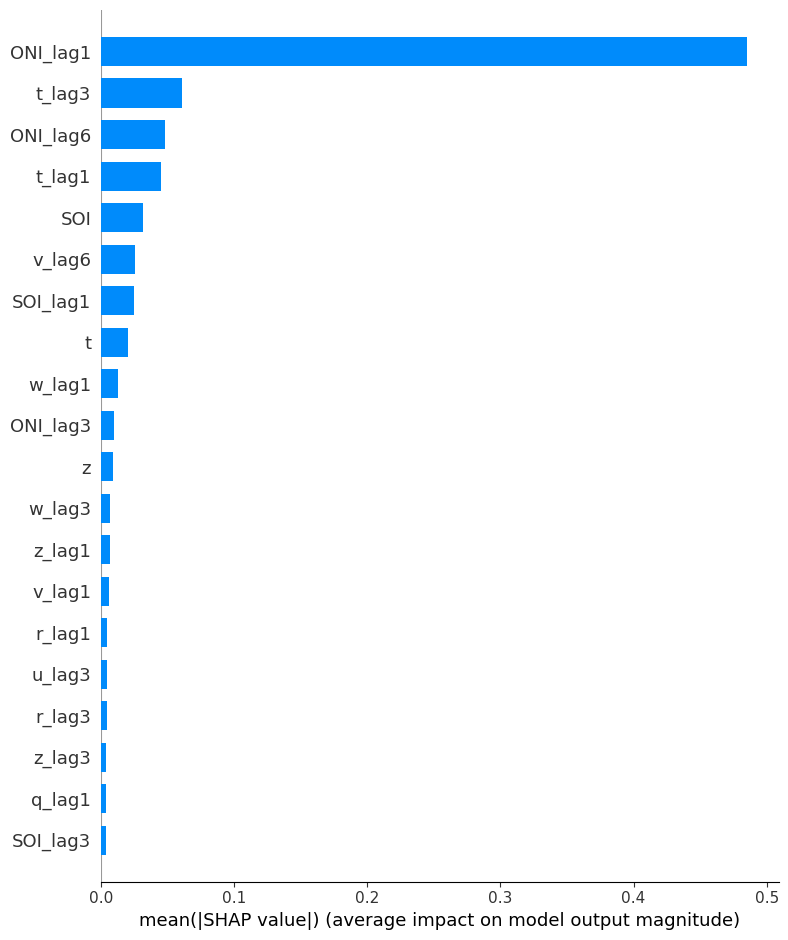

In [60]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## IMPLEMENT LINEAR REGRESSION

### Count NAN in X & Y

In [66]:
# Check total number of missing (NaN) values in feature dataset X
# .isna() → returns True/False for missing values
# .sum() → counts True values (NaNs) column-wise, then again sums all columns
print("NaNs in X:", X.isna().sum().sum())
# Check number of missing (NaN) values in target variable y
print("NaNs in y:", y.isna().sum())

NaNs in X: 0
NaNs in y: 0


In [67]:
# Combine X and y first
# This ensures that rows stay aligned when removing missing values
data = X.copy()
data["target"] = y

# Drop NaNs together
data = data.dropna()

# Split the cleaned dataset back into features (X) and target (y)
X = data.drop(columns=["target"])
y = data["target"]

### Test train Split

In [68]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# keeps chronological order instead of random shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

### Train Model

In [70]:
# This creates an empty model object that will learn relationships from data
lr_model = LinearRegression()

# X_train_scaled → input features (already scaled)
# y_train → target variable (ONI values)
# The model learns coefficients (weights) for each feature
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

### Make Prediction

In [71]:
# Use the trained Linear Regression model to make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

### Evalution

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Mean Absolute Error (MAE)
# Measures average absolute difference between actual and predicted values
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

# Calculate Root Mean Square Error (RMSE)
# Penalizes larger errors more than MAE (more sensitive to outliers)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate R² Score (Coefficient of Determination)
# Measures how well the model explains variance (1 = perfect, 0 = poor, negative = very bad)
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Performance:
MAE: 0.23644720449418613
RMSE: 0.3006258175194253
R2: 0.592048776906585


## IMPLEMENT SVR

In [73]:
from sklearn.svm import SVR
svr_model = SVR(
    kernel='rbf',   # nonlinear kernel (important for ENSO)
    C=1.0,          # regularization
    epsilon=0.1     # margin of error
)
svr_model.fit(X_train_scaled, y_train)

SVR()

### Prediction

In [74]:
# Use the trained SVR model to make predictions on test data
# X_test_scaled → scaled test features (same scaling as training data)
y_pred_svr = svr_model.predict(X_test_scaled)

### Evalution

In [75]:
# Calculate Mean Absolute Error (MAE) for SVR
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
# Calculate Root Mean Square Error (RMSE)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
# Calculate R² score
# Measures how well SVR explains the variance in data
r2_svr   = r2_score(y_test, y_pred_svr)
# Print SVR performance metrics
print("SVR Performance:")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2:", r2_svr)

SVR Performance:
MAE: 0.394540518706975
RMSE: 0.46667096595587076
R2: 0.0169462729931682


## IMPLEMENT XGBOOST

In [76]:

%pip install xgboost


In [77]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,     # number of trees
    learning_rate=0.05,   # step size
    max_depth=6,          # tree depth
    subsample=0.8,        # data sampling
    colsample_bytree=0.8, # feature sampling
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [87]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,     # number of trees
    learning_rate=0.05,   # step size
    max_depth=6,          # tree depth
    subsample=0.8,        # data sampling
    colsample_bytree=0.8, # feature sampling
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

### Prediction

In [88]:
y_pred_xgb = xgb_model.predict(X_test)

### Evalution

In [89]:
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Performance:
MAE: 0.25575293333083393
RMSE: 0.3255135813159848
R2: 0.5217071192891527


## STORE RESULT OF ALL MODELS

In [83]:
results = [
    ["Linear Regression", mae_lr, rmse_lr, r2_lr],
    ["SVR", mae_svr, rmse_svr, r2_svr],
    ["Random Forest", mae_rf, rmse_rf, r2_rf],
    ["XGBoost", mae_xgb, rmse_xgb, r2_xgb]
]

In [84]:
import pandas as pd
# Create a DataFrame from results list
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

# Sort models based on RMSE (ascending)
# Lower RMSE = better performance → best model will appear at top
results_df = results_df.sort_values(by="RMSE")

# Display the sorted results table
print(results_df)

               Model       MAE      RMSE        R2
2      Random Forest  0.206704  0.278714  0.649349
0  Linear Regression  0.236447  0.300626  0.592049
3            XGBoost  0.255753  0.325514  0.521707
1                SVR  0.394541  0.466671  0.016946


### Best Model

In [85]:

# Select the best model (first row after sorting by RMSE)
# Since we sorted ascending → index 0 = lowest RMSE (best model)
best_model = results_df.iloc[0]

print("Best Model Based on RMSE:")
print(best_model)

Best Model Based on RMSE:
Model    Random Forest
MAE           0.206704
RMSE          0.278714
R2            0.649349
Name: 2, dtype: object


### Model Performance Comparision

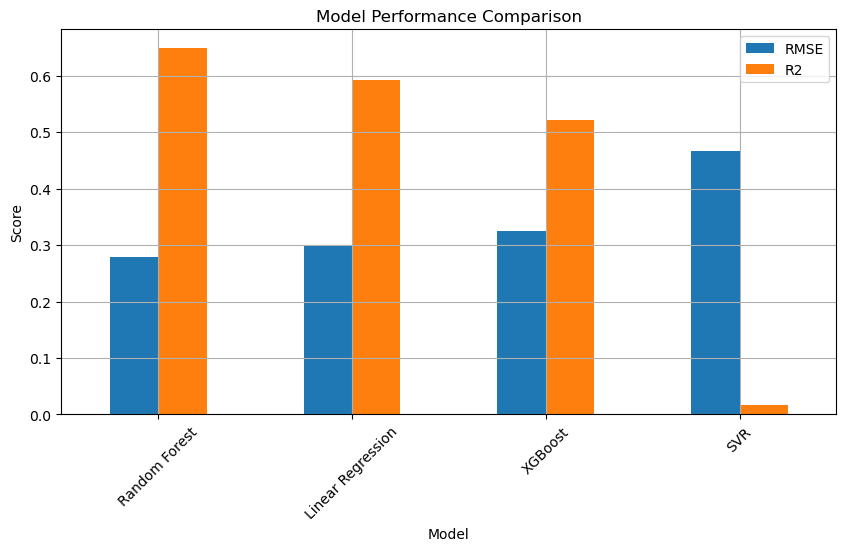

In [86]:
import matplotlib.pyplot as plt

# This creates a grouped bar chart for comparison
results_df.set_index("Model")[["RMSE", "R2"]].plot(kind="bar", figsize=(10,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

 ## XAI IMPLENTATION

## Summary Plot For Random Forest

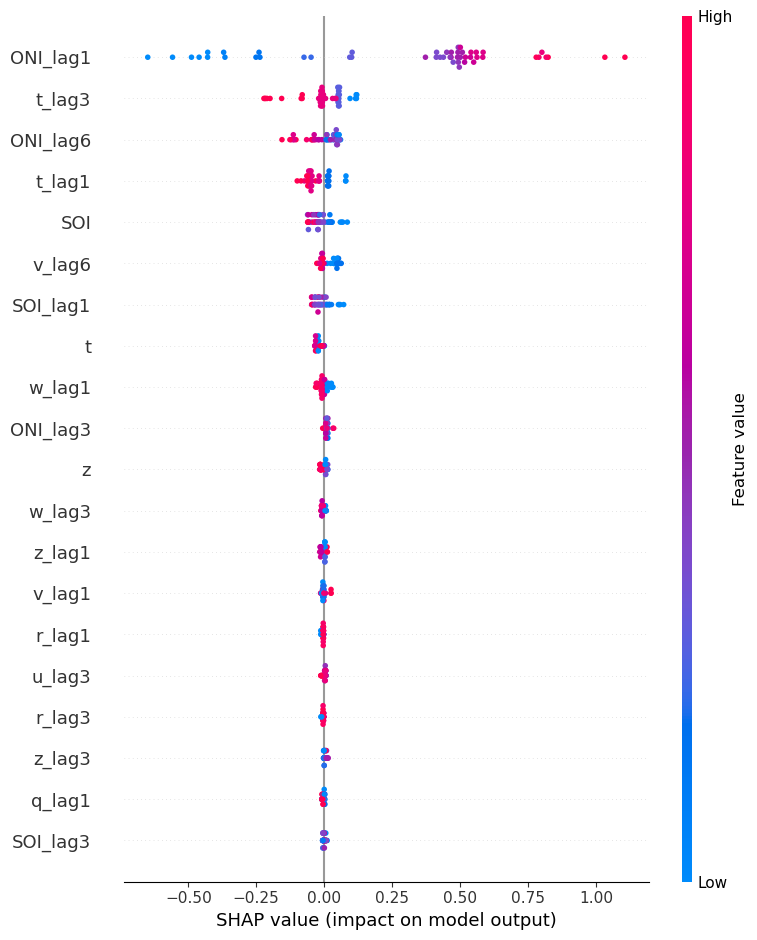

In [101]:
import shap

explainer_rf = shap.TreeExplainer(model)
shap_values_rf = explainer_rf.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values_rf, X_test)

### Summary Plot For XGBOOST

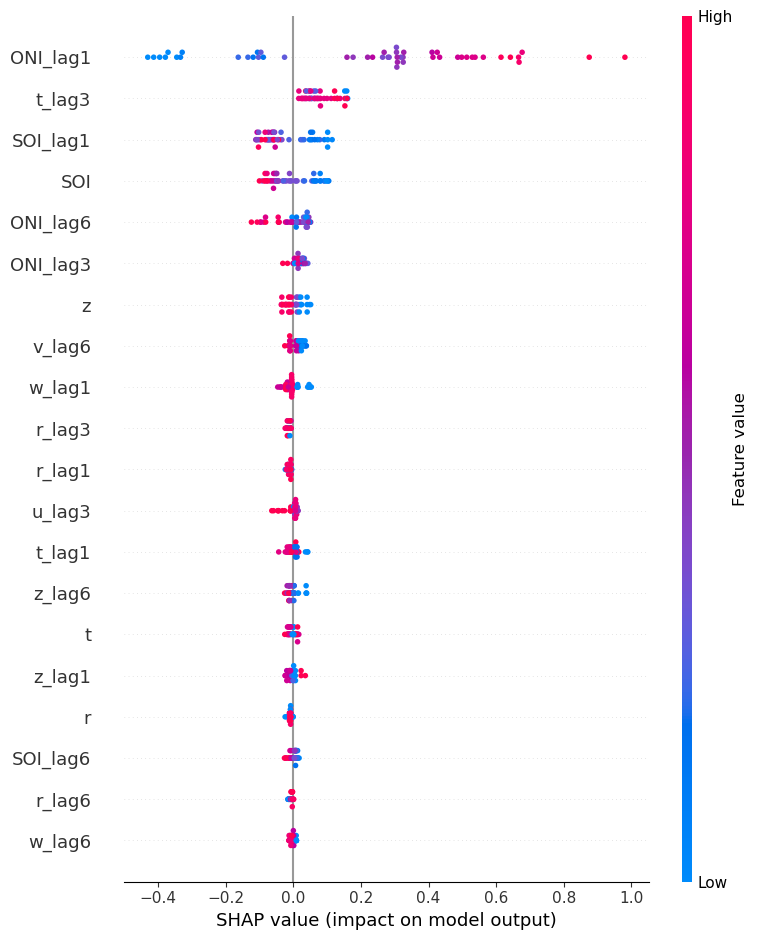

In [102]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test)

### Summary Plot For Linear Regression

  0%|          | 0/50 [00:00<?, ?it/s]

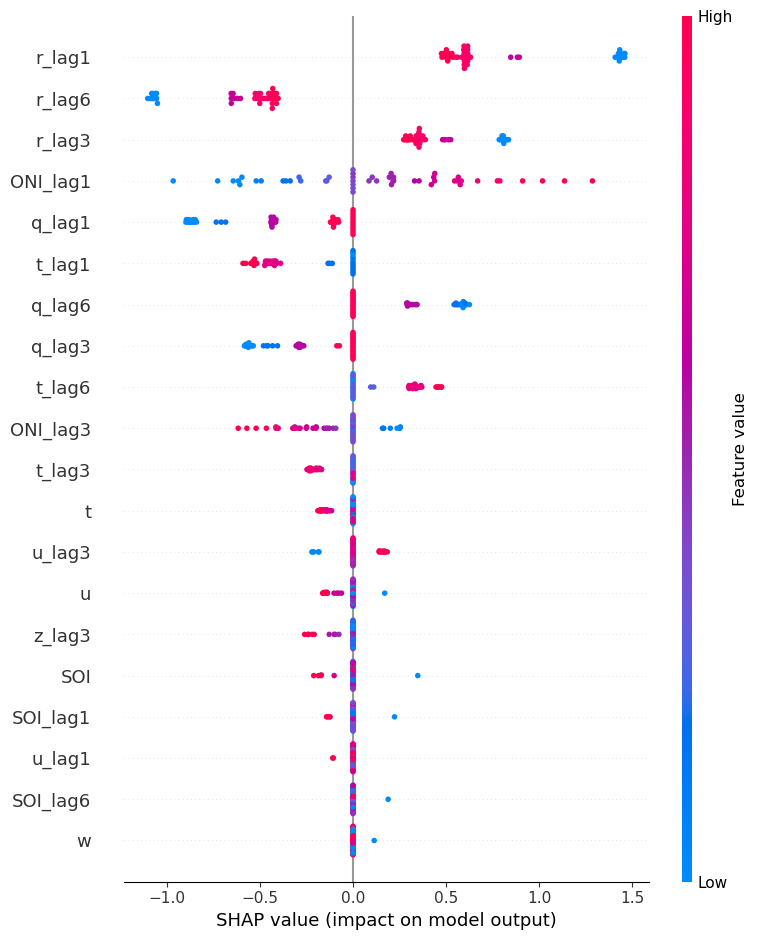

In [103]:
explainer_lr = shap.KernelExplainer(lr_model.predict, X_train_scaled[:100])

shap_values_lr = explainer_lr.shap_values(X_test_scaled[:50])

shap.summary_plot(shap_values_lr, X_test.iloc[:50])

# Assign Interpretability Scores

In [104]:
interpretability = {
    "Random Forest": 10,   # best (TreeExplainer + clear)
    "XGBoost": 9,          # very good
    "Linear Regression": 7, # moderate
    "SVR": 3               # poor
}

# Create Final Comparison Data

In [105]:
import pandas as pd

# Create a comparison DataFrame for all models
# This combines performance metrics and interpretability scores
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression", "XGBoost", "SVR"],
    "RMSE": [rmse_rf, rmse_lr, rmse_xgb, rmse_svr],
    "R2": [r2_rf, r2_lr, r2_xgb, r2_svr],
     # Interpretability scores (manually assigned based on SHAP usability)
    # Higher = easier to explain
    "Interpretability": [10, 7, 9, 3] 
})

# Plot 

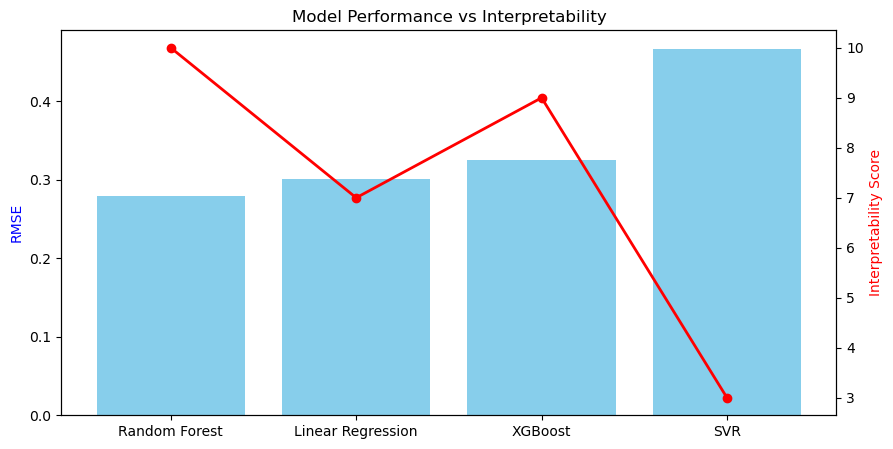

In [106]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# RMSE (left axis)
ax1.bar(comparison["Model"], comparison["RMSE"], color='skyblue', label='RMSE')
ax1.set_ylabel("RMSE", color='blue')

# Interpretability (right axis)
ax2 = ax1.twinx()
ax2.plot(comparison["Model"], comparison["Interpretability"], 
         color='red', marker='o', linewidth=2, label='Interpretability')
ax2.set_ylabel("Interpretability Score", color='red')

plt.title("Model Performance vs Interpretability")
plt.xticks(rotation=30)

plt.show()

 ### Blue Bars → RMSE (Left Axis)
Lower value = better accuracy

Shows how well each model predicts ONI

### Red Line → Interpretability Score (Right Axis)
Higher value = easier to explain

Based on how well SHAP works for each model

